<a href="https://colab.research.google.com/github/mathewhaiden74/Shortest-path-Finder/blob/main/Shortest_path.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install geopandas

Loading store locations...
Calculating distances between all stores...
Running optimization to find the shortest route...
Optimal sequence to visit stores: [0, 2, 5, 3, 1, 4, 0]
Generating map image...


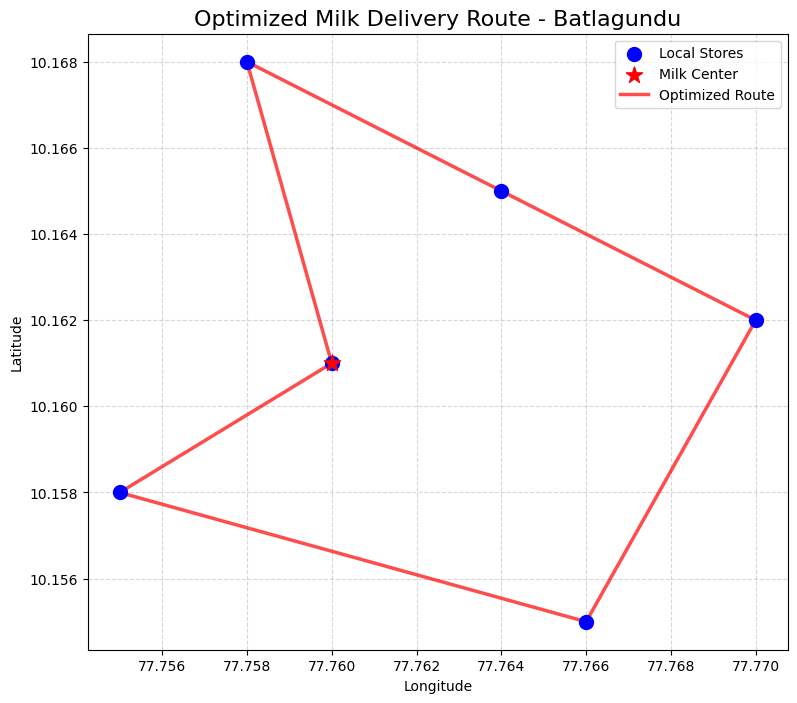

In [ ]:
!pip install --upgrade networkx
# Please restart the runtime (Runtime -> Restart runtime...) after running this cell
# and then re-execute this cell to ensure the upgraded networkx is loaded.

import geopandas as gpd
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
from scipy.spatial import distance_matrix
from shapely.geometry import Point

# --- 1. Load the Data ---
print("Loading store locations...")
# If you haven't created your new store points shapefile yet,
# you can test this with mock data by leaving the next block uncommented.
# Once you upload your real shapefile, delete the mock data block and uncomment the read_file line.

# --- MOCK DATA BLOCK (Delete when using real files) ---
lats = [10.161, 10.165, 10.158, 10.162, 10.168, 10.155]
lons = [77.760, 77.764, 77.755, 77.770, 77.758, 77.766]
geometry = [Point(xy) for xy in zip(lons, lats)]
stores_gdf = gpd.GeoDataFrame({'Store_ID': range(len(geometry))}, geometry=geometry, crs="EPSG:4326")
# ------------------------------------------------------

# --- REAL DATA LINE (Uncomment and change filename when ready) ---
# stores_gdf = gpd.read_file("your_store_points.shp")

# Extract coordinates
coords = np.array([(geom.x, geom.y) for geom in stores_gdf.geometry])

# --- 2. Calculate Distances ---
print("Calculating distances between all stores...")
dist_matrix = distance_matrix(coords, coords)

# --- 3. Run Optimization (Traveling Salesperson Problem) ---
print("Running optimization to find the shortest route...")
G = nx.Graph()
for i in range(len(coords)):
    for j in range(len(coords)):
        if i != j:
            G.add_edge(i, j, weight=dist_matrix[i][j])

# Solve for the shortest loop
tsp_path = nx.approximation.traveling_salesman_problem(G, cycle=True)
print(f"Optimal sequence to visit stores: {tsp_path}")

# --- 4. Visualize and Save Output ---
print("Generating map image...")
fig, ax = plt.subplots(figsize=(10, 8))

# Plot all local stores
stores_gdf.plot(ax=ax, color='blue', markersize=100, label='Local Stores', zorder=5)

# Plot the starting point (Milk Distribution Center)
start_point = stores_gdf.iloc[[tsp_path[0]]]
start_point.plot(ax=ax, color='red', markersize=150, marker='*', label='Milk Center', zorder=6)

# Draw the route
route_coords = [coords[i] for i in tsp_path]
route_xs, route_ys = zip(*route_coords)
ax.plot(route_xs, route_ys, color='red', linewidth=2.5, linestyle='-', alpha=0.7, label='Optimized Route')

# Formatting
ax.set_title("Optimized Milk Delivery Route - Batlagundu", fontsize=16)
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.legend()
ax.grid(True, linestyle='--', alpha=0.5)

# Save the image inside Colab
plt.savefig("Optimized_Milk_Route.jpg", dpi=300, bbox_inches='tight')

# Display the image right below the cell
plt.show()

!pip install --upgrade networkx
# Please restart the runtime (Runtime -> Restart runtime...) after running this cell
# and then re-execute this cell to ensure the upgraded networkx is loaded.

import geopandas as gpd
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
from scipy.spatial import distance_matrix
from shapely.geometry import Point

# --- 1. Load the Data ---
print("Loading store locations...")
# If you haven't created your new store points shapefile yet,
# you can test this with mock data by leaving the next block uncommented.
# Once you upload your real shapefile, delete the mock data block and uncomment the read_file line.

# --- MOCK DATA BLOCK (Delete when using real files) ---
lats = [10.161, 10.165, 10.158, 10.162, 10.168, 10.155]
lons = [77.760, 77.764, 77.755, 77.770, 77.758, 77.766]
geometry = [Point(xy) for xy in zip(lons, lats)]
stores_gdf = gpd.GeoDataFrame({'Store_ID': range(len(geometry))}, geometry=geometry, crs="EPSG:4326")
# ------------------------------------------------------

# --- REAL DATA LINE (Uncomment and change filename when ready) ---
# stores_gdf = gpd.read_file("your_store_points.shp")

# Extract coordinates
coords = np.array([(geom.x, geom.y) for geom in stores_gdf.geometry])

# --- 2. Calculate Distances ---
print("Calculating distances between all stores...")
dist_matrix = distance_matrix(coords, coords)

# --- 3. Run Optimization (Traveling Salesperson Problem) ---
print("Running optimization to find the shortest route...")
G = nx.Graph()
for i in range(len(coords)):
    for j in range(len(coords)):
        if i != j:
            G.add_edge(i, j, weight=dist_matrix[i][j])

# Solve for the shortest loop
tsp_path = nx.approximation.traveling_salesman_problem(G, cycle=True)
print(f"Optimal sequence to visit stores: {tsp_path}")

# --- 4. Visualize and Save Output ---
print("Generating map image...")
fig, ax = plt.subplots(figsize=(10, 8))

# Plot all local stores
stores_gdf.plot(ax=ax, color='blue', markersize=100, label='Local Stores', zorder=5)

# Plot the starting point (Milk Distribution Center)
start_point = stores_gdf.iloc[[tsp_path[0]]]
start_point.plot(ax=ax, color='red', markersize=150, marker='*', label='Milk Center', zorder=6)

# Draw the route
route_coords = [coords[i] for i in tsp_path]
route_xs, route_ys = zip(*route_coords)
ax.plot(route_xs, route_ys, color='red', linewidth=2.5, linestyle='-', alpha=0.7, label='Optimized Route')

# Formatting
ax.set_title("Optimized Milk Delivery Route - Batlagundu", fontsize=16)
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.legend()
ax.grid(True, linestyle='--', alpha=0.5)

# Save the image inside Colab
plt.savefig("Optimized_Milk_Route.jpg", dpi=300, bbox_inches='tight')

# Display the image right below the cell
plt.show()




In [ ]:
import networkx as nx
print(nx.__version__)

3.6.1


In [ ]:
!pip install osmnx

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 104.4/104.4 kB 1.3 MB/s eta 0:00:00


1. Setting up store locations...
2. Downloading actual road network for the area...
3. Snapping stores to the nearest real roads...
4. Calculating actual driving distances between stores...
5. Running optimization for the shortest road loop...
Optimal visiting sequence: [0, 1, 3, 5, 4, 2, 0]
6. Generating the full route along the streets...
7. Drawing the map...


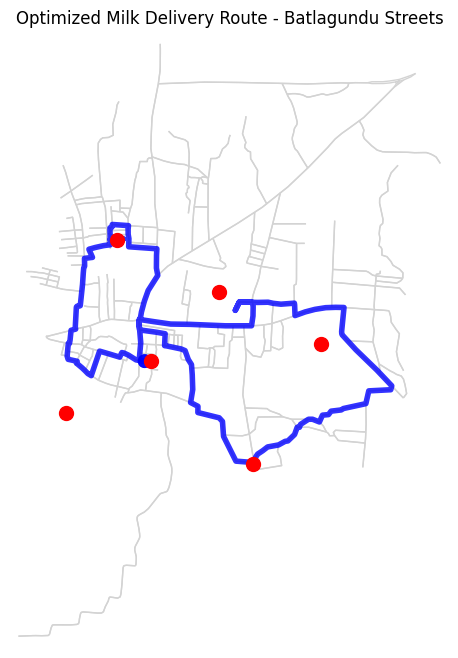

In [ ]:
import osmnx as ox
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np

# 1. Define store locations
print("1. Setting up store locations...")
lats = [10.161, 10.165, 10.158, 10.162, 10.168, 10.155]
lons = [77.760, 77.764, 77.755, 77.770, 77.758, 77.766]

# 2. Download actual road network around the center of the stores
print("2. Downloading actual road network for the area...")
center_lat = np.mean(lats)
center_lon = np.mean(lons)
# Downloading a 2km radius around the center of the points
G = ox.graph_from_point((center_lat, center_lon), dist=2000, network_type='drive')

print("3. Snapping stores to the nearest real roads...")
# Find the closest physical street intersections for each coordinate
store_nodes = ox.distance.nearest_nodes(G, X=lons, Y=lats)

print("4. Calculating actual driving distances between stores...")
# Build a distance matrix using the road network instead of straight lines
tsp_graph = nx.Graph()
for i in range(len(store_nodes)):
    for j in range(len(store_nodes)):
        if i != j:
            try:
                dist = nx.shortest_path_length(G, store_nodes[i], store_nodes[j], weight='length')
                tsp_graph.add_edge(i, j, weight=dist)
            except nx.NetworkXNoPath:
                tsp_graph.add_edge(i, j, weight=float('inf'))

print("5. Running optimization for the shortest road loop...")
tsp_path_indices = nx.approximation.traveling_salesman_problem(tsp_graph, cycle=True)
print(f"Optimal visiting sequence: {tsp_path_indices}")

print("6. Generating the full route along the streets...")
full_route = []
for k in range(len(tsp_path_indices) - 1):
    start_node = store_nodes[tsp_path_indices[k]]
    end_node = store_nodes[tsp_path_indices[k+1]]
    path = nx.shortest_path(G, start_node, end_node, weight='length')
    full_route.extend(path[:-1])

full_route.append(store_nodes[tsp_path_indices[-1]])

print("7. Drawing the map...")
fig, ax = ox.plot_graph_route(
    G,
    full_route,
    route_color='blue',
    route_linewidth=4,
    route_alpha=0.8,
    node_size=0,
    bgcolor='white',
    edge_color='lightgray',
    show=False,
    close=False
)

ax.scatter(lons, lats, c='red', s=100, zorder=5, label='Stores & Milk Center')
plt.title("Optimized Milk Delivery Route - Batlagundu Streets")
plt.savefig("Batlagundu_Road_Route.jpg", dpi=300, bbox_inches='tight')
plt.show()

1. Setting up store locations...
2. Downloading actual road network for Batlagundu area...
3. Snapping stores to the nearest real roads...
4. Calculating actual driving distances between stores...
5. Running optimization for the shortest road loop...
6. Generating the full route along the streets...
7. Drawing the map with actual names...


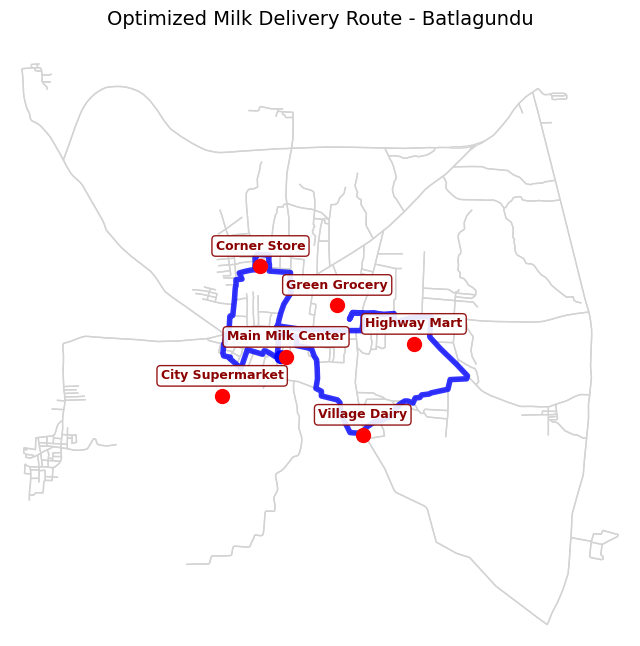

In [ ]:
import osmnx as ox
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np

# 1. Define store locations and actual names
print("1. Setting up store locations...")
lats = [10.161, 10.165, 10.158, 10.162, 10.168, 10.155]
lons = [77.760, 77.764, 77.755, 77.770, 77.758, 77.766]

# Edit these names to match your actual store names
labels = [
    "Main Milk Center",
    "Green Grocery",
    "City Supermarket",
    "Highway Mart",
    "Corner Store",
    "Village Dairy"
]

# 2. Download actual road network using a point and distance
print("2. Downloading actual road network for Batlagundu area...")
center_lat = np.mean(lats)
center_lon = np.mean(lons)
G = ox.graph_from_point((center_lat, center_lon), dist=2500, network_type='drive')

print("3. Snapping stores to the nearest real roads...")
store_nodes = ox.distance.nearest_nodes(G, X=lons, Y=lats)

print("4. Calculating actual driving distances between stores...")
tsp_graph = nx.Graph()
for i in range(len(store_nodes)):
    for j in range(len(store_nodes)):
        if i != j:
            try:
                dist = nx.shortest_path_length(G, store_nodes[i], store_nodes[j], weight='length')
                tsp_graph.add_edge(i, j, weight=dist)
            except nx.NetworkXNoPath:
                tsp_graph.add_edge(i, j, weight=float('inf'))

print("5. Running optimization for the shortest road loop...")
tsp_path_indices = nx.approximation.traveling_salesman_problem(tsp_graph, cycle=True)

print("6. Generating the full route along the streets...")
full_route = []
for k in range(len(tsp_path_indices) - 1):
    start_node = store_nodes[tsp_path_indices[k]]
    end_node = store_nodes[tsp_path_indices[k+1]]
    path = nx.shortest_path(G, start_node, end_node, weight='length')
    full_route.extend(path[:-1])
full_route.append(store_nodes[tsp_path_indices[-1]])

print("7. Drawing the map with actual names...")
fig, ax = ox.plot_graph_route(
    G, full_route, route_color='blue', route_linewidth=4,
    route_alpha=0.8, node_size=0, bgcolor='white',
    edge_color='lightgray', show=False, close=False
)

ax.scatter(lons, lats, c='red', s=100, zorder=5)

for i, label in enumerate(labels):
    ax.annotate(
        label,
        (lons[i], lats[i]),
        textcoords="offset points",
        xytext=(0, 12),
        ha='center',
        fontsize=9,
        fontweight='bold',
        color='darkred',
        zorder=6,
        bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="darkred", alpha=0.9)
    )

plt.title("Optimized Milk Delivery Route - Batlagundu", fontsize=14, pad=20)
plt.savefig("Batlagundu_Road_Route_Named.jpg", dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
import osmnx as ox
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.lines import Line2D

if 'combined_stores_gdf' in locals():
    lats = combined_stores_gdf.geometry.y.tolist()
    lons = combined_stores_gdf.geometry.x.tolist()
    labels = combined_stores_gdf['Name'].tolist()

    # 1. Download road network
    center_lat, center_lon = np.mean(lats), np.mean(lons)
    print('Downloading high-detail street map...')
    G_ultra = ox.graph_from_point((center_lat, center_lon), dist=1000, network_type='drive')

    # 2. Setup Routing with 'Hap daily' as Start
    store_nodes = ox.distance.nearest_nodes(G_ultra, X=lons, Y=lats)

    try:
        start_index = labels.index('Hap daily')
    except ValueError:
        start_index = 0

    tsp_graph = nx.Graph()
    for i in range(len(store_nodes)):
        for j in range(len(store_nodes)):
            if i != j:
                try:
                    dist = nx.shortest_path_length(G_ultra, store_nodes[i], store_nodes[j], weight='length')
                    tsp_graph.add_edge(i, j, weight=dist)
                except: tsp_graph.add_edge(i, j, weight=1e9)

    tsp_path_indices = nx.approximation.traveling_salesman_problem(tsp_graph, cycle=True, nodes=list(range(len(labels))))
    start_pos = tsp_path_indices.index(start_index)
    tsp_path_indices = tsp_path_indices[start_pos:] + tsp_path_indices[1:start_pos+1]

    full_route = []
    for k in range(len(tsp_path_indices) - 1):
        try:
            p = nx.shortest_path(G_ultra, store_nodes[tsp_path_indices[k]], store_nodes[tsp_path_indices[k+1]], weight='length')
            full_route.extend(p[:-1])
        except: continue
    full_route.append(store_nodes[tsp_path_indices[-1]])

    # 3. Enhanced Visualization
    fig, ax = ox.plot_graph_route(G_ultra, full_route, route_color='#1a73e8', route_linewidth=4,
                                 node_size=0, bgcolor='white', edge_color='#eeeeee',
                                 show=False, close=False, figsize=(16, 12))

    # Generate 17 distinct colors
    cmap = plt.get_cmap('tab20')
    colors = [cmap(i) for i in range(len(labels))]

    # 4. Plot Dots with unique colors
    legend_elements = []
    for i in range(len(lons)):
        marker_size = 300 if i == start_index else 150
        marker_style = '*' if i == start_index else 'o'
        ax.scatter(lons[i], lats[i], c=[colors[i]], s=marker_size,
                   edgecolors='black', linewidth=1.5, zorder=15, marker=marker_style)

        # Create legend entry
        entry_name = f"{labels[i]} (Start)" if i == start_index else labels[i]
        legend_elements.append(Line2D([0], [0], marker=marker_style, color='w',
                                      label=entry_name, markerfacecolor=colors[i],
                                      markersize=12, markeredgecolor='black'))

    # Add legend to top right
    ax.legend(handles=legend_elements, loc='upper right', bbox_to_anchor=(1.35, 1.0),
              title="Delivery Locations", fontsize=10, title_fontsize=12,
              frameon=True, facecolor='white', edgecolor='gray')

    # Title removed per user request
    plt.savefig('Store_Dots_With_Legend.jpg', dpi=300, bbox_inches='tight')
    plt.show()
else:
    print('Please ensure combined_stores_gdf is loaded.')

Please ensure combined_stores_gdf is loaded.


In [ ]:
import osmnx as ox
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np

if 'combined_stores_gdf' in locals():
    # 1. Extract Coords and Names
    lats = combined_stores_gdf.geometry.y.tolist()
    lons = combined_stores_gdf.geometry.x.tolist()
    labels = combined_stores_gdf['Name'].tolist()

    # 2. Download a tighter road network (Zoomed in to 1.5km instead of 4km)
    center_lat, center_lon = np.mean(lats), np.mean(lons)
    print("Downloading zoomed-in road network...")
    # Smaller 'dist' creates the zoom effect
    G_zoom = ox.graph_from_point((center_lat, center_lon), dist=1500, network_type='drive')

    # 3. Use the same route logic but on the zoomed map
    store_nodes = ox.distance.nearest_nodes(G_zoom, X=lons, Y=lats)

    # Re-calculating TSP on the zoomed graph to ensure connectivity
    tsp_graph = nx.Graph()
    for i in range(len(store_nodes)):
        for j in range(len(store_nodes)):
            if i != j:
                try:
                    dist = nx.shortest_path_length(G_zoom, store_nodes[i], store_nodes[j], weight='length')
                    tsp_graph.add_edge(i, j, weight=dist)
                except:
                    tsp_graph.add_edge(i, j, weight=1e9)

    tsp_path_indices = nx.approximation.traveling_salesman_problem(tsp_graph, cycle=True)

    full_route = []
    for k in range(len(tsp_path_indices) - 1):
        p = nx.shortest_path(G_zoom, store_nodes[tsp_path_indices[k]], store_nodes[tsp_path_indices[k+1]], weight='length')
        full_route.extend(p[:-1])
    full_route.append(store_nodes[tsp_path_indices[-1]])

    # 4. High-detail visualization
    fig, ax = ox.plot_graph_route(G_zoom, full_route, route_color='#0055ff', route_linewidth=5,
                                 node_size=0, bgcolor='white', edge_color='#cccccc',
                                 show=False, close=False)

    # Plot stores with larger markers
    ax.scatter(lons, lats, c='red', s=80, edgecolors='black', zorder=10)

    # Add labels with better clarity
    for i, label in enumerate(labels):
        ax.annotate(label, (lons[i], lats[i]),
                    textcoords="offset points", xytext=(0,10),
                    ha='center', fontsize=9, fontweight='bold', color='black',
                    bbox=dict(boxstyle="round,pad=0.2", fc="white", alpha=0.8, ec='red', lw=1),
                    zorder=11)

    plt.title(f"Detailed Delivery Map: {len(labels)} Local Stores", fontsize=16, pad=20)
    plt.savefig("Zoomed_Store_Map.jpg", dpi=300, bbox_inches='tight')
    plt.show()
else:
    print("Please run the merging cell first to load the 17 stores.")

Please run the merging cell first to load the 17 stores.


In [ ]:
import geopandas as gpd
import pandas as pd
import glob
import os

# Find all shapefiles in the content directory
shp_files = glob.glob("/content/*.shp")
# Filter out the 'Batlagundu_Shortest_Route' and 'points' files to avoid duplicates if they were just exports
exclude = ["points.shp", "Batlagundu_Shortest_Route.shp"]
shp_files = [f for f in shp_files if os.path.basename(f) not in exclude]

all_stores = []
for f in shp_files:
    try:
        gdf = gpd.read_file(f)
        all_stores.append(gdf)
    except Exception as e:
        print(f"Could not read {f}: {e}")

if all_stores:
    # Merge all individual store GeoDataFrames
    combined_stores_gdf = pd.concat(all_stores, ignore_index=True)
    # Drop duplicates if any stores were repeated across files based on geometry
    combined_stores_gdf = combined_stores_gdf.drop_duplicates(subset=['geometry'])

    print(f"Total stores found across all files: {len(combined_stores_gdf)}")
    display(combined_stores_gdf[['Name', 'geometry']].head(20))
else:
    print("No individual store shapefiles found.")

Total stores found across all files: 17


,Name,geometry
0,Raja store,POINT Z (77.76531 10.16296 0)
1,Naveen Bakery,POINT Z (77.7557 10.17651 0)
2,Kalaimagal store,POINT Z (77.75862 10.16204 0)
3,Hap daily,POINT Z (77.75419 10.1625 0)
4,Ayyappa store,POINT Z (77.75866 10.16176 0)
5,Jamuna bakery,POINT Z (77.75375 10.1625 0)
6,Iyengar Bakery,POINT Z (77.75613 10.16291 0)
7,Ponsrinithi Generals,POINT Z (77.75529 10.17068 0)
8,Sri maligai,POINT Z (77.75934 10.16277 0)
9,Pushpam store,POINT Z (77.75593 10.16871 0)


Optimizing route for 16 stores...


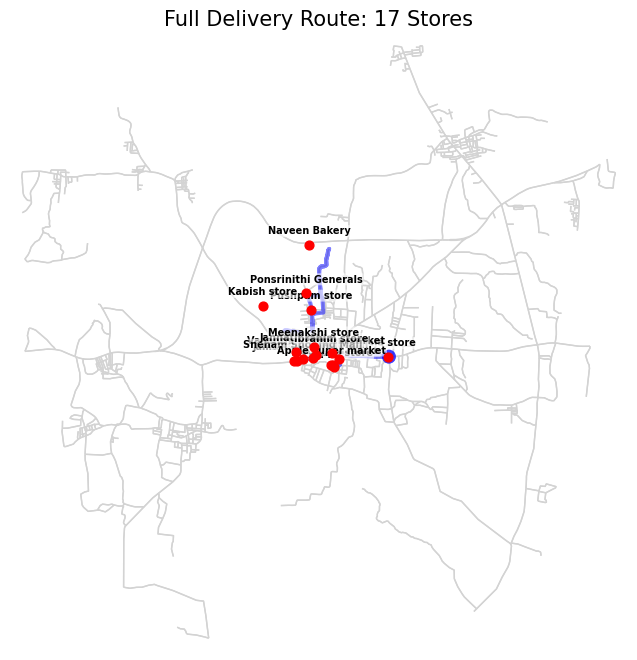

In [ ]:
import osmnx as ox
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np

if 'combined_stores_gdf' in locals():
    # 1. Extract Coords and Names
    lats = combined_stores_gdf.geometry.y.tolist()
    lons = combined_stores_gdf.geometry.x.tolist()
    labels = combined_stores_gdf['Name'].tolist()

    # 2. Download a larger road network to fit all 16 points
    center_lat, center_lon = np.mean(lats), np.mean(lons)
    print("Downloading road network for all stores...")
    G = ox.graph_from_point((center_lat, center_lon), dist=4000, network_type='drive')

    # 3. Find road nodes and calculate TSP
    store_nodes = ox.distance.nearest_nodes(G, X=lons, Y=lats)

    tsp_graph = nx.Graph()
    for i in range(len(store_nodes)):
        for j in range(len(store_nodes)):
            if i != j:
                try:
                    dist = nx.shortest_path_length(G, store_nodes[i], store_nodes[j], weight='length')
                    tsp_graph.add_edge(i, j, weight=dist)
                except:
                    tsp_graph.add_edge(i, j, weight=1e9)

    print("Optimizing route for 16 stores...")
    tsp_path_indices = nx.approximation.traveling_salesman_problem(tsp_graph, cycle=True)

    full_route = []
    for k in range(len(tsp_path_indices) - 1):
        p = nx.shortest_path(G, store_nodes[tsp_path_indices[k]], store_nodes[tsp_path_indices[k+1]], weight='length')
        full_route.extend(p[:-1])
    full_route.append(store_nodes[tsp_path_indices[-1]])

    # 4. Large scale visualization
    fig, ax = ox.plot_graph_route(G, full_route, route_color='blue', route_linewidth=3, node_size=0,
                                 bgcolor='white', edge_color='lightgray', show=False, close=False)

    ax.scatter(lons, lats, c='red', s=40, zorder=5)

    for i, label in enumerate(labels):
        ax.annotate(label, (lons[i], lats[i]), textcoords="offset points", xytext=(0,8),
                    ha='center', fontsize=7, fontweight='bold',
                    bbox=dict(boxstyle="round,pad=0.1", fc="white", alpha=0.6, ec='none'))

    plt.title(f"Full Delivery Route: {len(labels)} Stores", fontsize=15)
    plt.savefig("Full_16_Store_Route.jpg", dpi=300, bbox_inches='tight')
    plt.show()
else:
    print("Please run the merging cell above first.")

In [ ]:
import geopandas as gpd

# Load the uploaded shapefile
# Assuming 'points.shp' is the main list, or change to another filename if needed
try:
    stores_gdf = gpd.read_file('points.shp')
    print("File loaded successfully!")
    display(stores_gdf.head())
    print("Available columns:", stores_gdf.columns.tolist())
except Exception as e:
    print(f"Error: {e}. Please check if 'points.shp' is the correct filename.")

File loaded successfully!


,id,Name,descriptio,timestamp,begin,end,altitudeMo,tessellate,extrude,visibility,drawOrder,icon,geometry
0,None,Pushpam store,None,None,None,None,None,-1,0,-1,0,None,POINT Z (77.75593 10.16871 0)
1,None,Raja store,None,None,None,None,None,-1,0,-1,0,None,POINT Z (77.76531 10.16296 0)
2,None,Sneham Shoping Mall,None,None,None,None,None,-1,0,-1,0,None,POINT Z (77.75487 10.16277 0)
3,None,Sri maligai,None,None,None,None,None,-1,0,-1,0,None,POINT Z (77.75934 10.16277 0)
4,None,Vasantham super market,None,None,None,None,None,-1,0,-1,0,None,POINT Z (77.75646 10.16324 0)


Available columns: ['id', 'Name', 'descriptio', 'timestamp', 'begin', 'end', 'altitudeMo', 'tessellate', 'extrude', 'visibility', 'drawOrder', 'icon', 'geometry']
